# Файлы

**Файл (англ. file)** — именованная область данных на носителе информации

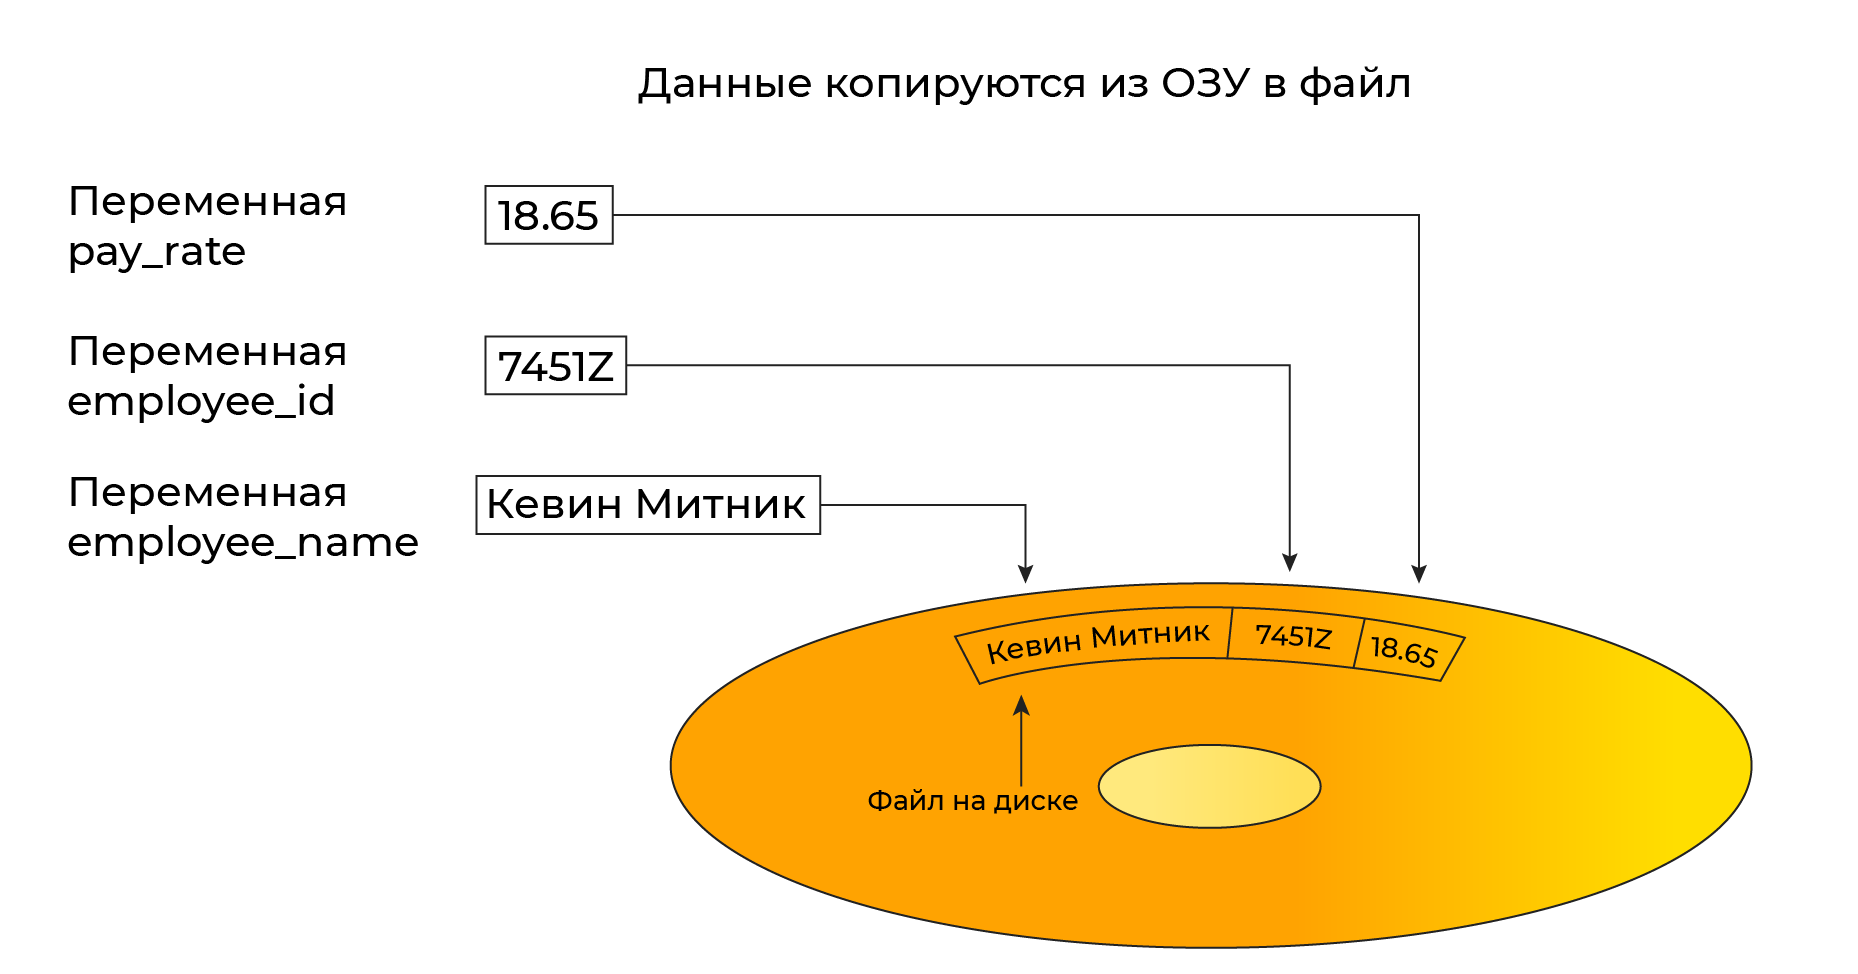

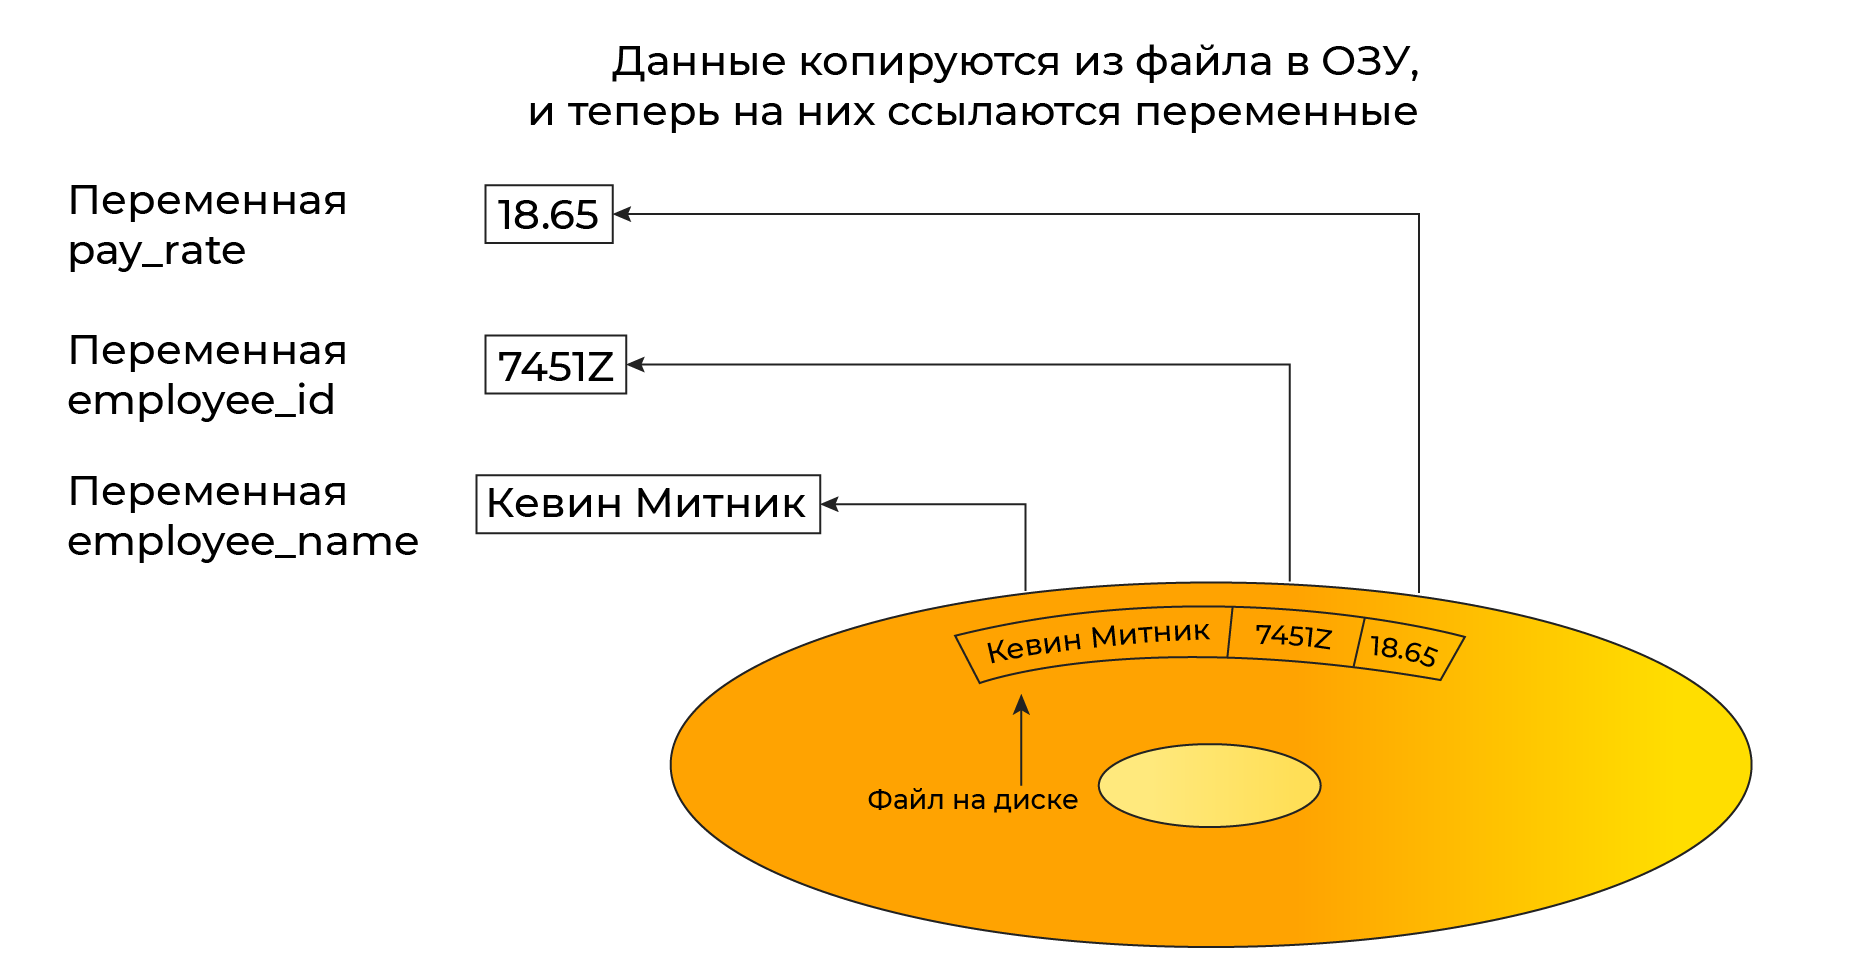

1. **Открыть файл.** В процессе открытия файла создается связь между файлом и программой. Открытие файла вывода обычно создает файл на диске и позволяет программе записать в него данные. Открытие файла ввода позволяет программе прочитать данные из файла.
2. **Обработать файл.** На этом шаге данные либо записываются в файл (если это файл вывода), либо считываются из файла (если это файл ввода).
3. **Закрыть файл.** После использования файла программой его нужно закрыть, тем самым освободить ресурс и разорвать связь файла с программой.

* ``open('students.txt', 'r',encoding='utf-8')``
* ``.close()``
* ``.closed``
------
* ``read()`` - читает все содержимое файла и перемещает курсор в конец файла
* ``.readline()`` - читает строку и перемещает курсор на следующую строку
* ``.readlines`` - выдает список строк и перемещает курсор в конец файла
-----
При открытии файла курсор всегда = 0.
* ``.seek()`` - задает позицию курсора в байтах от начала файла. (полезен в работе с файлами с двоичным кодом)
* ``.tell()`` - получает текущую позицию
------
* ``.write()``– записывает переданную строку в файл;
* ``.writelines()``– записывает переданный список строк в файл.

**Менеджер контекста**

если между открытием файла и его закрытием произойдёт ошибка, в лучшем случае файл окажется открыт слишком долго, а в худшем случае часть данных не сохранится.
```Python
with object as name:
    # Здесь нам доступен ресурс name.
    # Это тело with-блока.
# А здесь ресурс name уже освобождён, даже если в теле with-блока произошла ошибка.
```

Хочется иметь возможность автоматически закрывать файл сразу после окончания работы с ним и осуществлять закрытие даже при возникновении ошибки. Файловые объекты уже умеют работать в таком режиме, но для этого их нужно использовать как менеджеры контекста.

Весь код в теле ``with``-блока работает "в контексте". Чаще всего контекст подразумевает выделение некоего ресурса, например, файла. По выходу из контекста ресурс автоматически освобождается, даже если при выполнении блока возникло исключение.

Как только закончится код, оформленный с отступами в ``with`` (аналогичные отступы в циклах или функциях), это будет означать, что контекст закончился, и Python автоматически закроет файл.

Приведенный ниже код:
```Python
file = open('languages.txt', 'r', encoding='utf-8')
for line in file:
    print(line)
file.close()              # ручное закрытие файла
print('Файл закрыт')
```
можно переписать в виде:
```Python
with open('languages.txt', 'r', encoding='utf-8') as file:
    for line in file:
        print(line)
 # автоматическое закрытие файла
print('Файл закрыт')
```

In [ ]:
inf= open('file.txt','r')
s1=inf.readline()
s2=inf.readline()
inf.close()

Тоже самое, но автоматически закрывает файл после окончания.

In [ ]:
with open('text.txt') as inf:
    s1=inf.readline()
    s2=inf.readline()

Убераем все служебные символы при чтении строки

In [ ]:
s=inf.readline().strip()

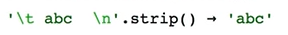

Строим полный путь к файлу. 

In [ ]:
os.path.join('.','dirname','filename.txt')


**Построчное чтение файла**

In [ ]:
with open('input.txt') as inf:
    for line in inf:
        line=line.strip()
        print(line)

**Запись в файл**

In [79]:
ouf=open('file.txt','w')
ouf.write('Some text\n')
ouf.write(str(25)) # Надо тип явно преобразовать в строку
ouf.close()

In [80]:
with open('text.txt','w') as ouf:
    ouf.write('some text\n')
    ouf.write(str(25))

## Задача 1

Недавно мы считали для каждого слова количество его вхождений в строку. Но на все слова может быть не так интересно смотреть, как, например, на наиболее часто используемые.

Напишите программу, которая считывает текст из файла (в файле может быть больше одной строки) и выводит самое частое слово в этом тексте и через пробел то, сколько раз оно встретилось. Если таких слов несколько, вывести лексикографически первое (можно использовать оператор < для строк).

В качестве ответа укажите вывод программы, а не саму программу.

Слова, написанные в разных регистрах, считаются одинаковыми.

**Sample Input:**
```
abc a bCd bC AbC BC BCD bcd ABC
```
--------------------------------------------
**Sample Output:**
```
abc 3
```

In [96]:
slov={}
with open(r'C:\Users\79618\Downloads\dataset_3363_3.txt','r') as inf:
    for line in inf:
        line=line.strip().lower()
        line=line.split()
        for i in line:
            if i not in slov.keys():
                slov[i]=1
            else:
                slov[i]=slov[i]+1
print(max(slov,key=slov.get), slov[max(slov,key=slov.get)])

dzcctp 8


## Задача 2

Имеется файл с данными по успеваемости абитуриентов. Он представляет из себя набор строк, где в каждой строке записана следующая информация:

Фамилия;Оценка_по_математике;Оценка_по_физике;Оценка_по_русскому_языку

Поля внутри строки разделены точкой с запятой, оценки — целые числа.

Напишите программу, которая считывает исходный файл с подобной структурой и для каждого абитуриента записывает его среднюю оценку по трём предметам на отдельной строке, соответствующей этому абитуриенту, в файл с ответом.

Также вычислите средние баллы по математике, физике и русскому языку по всем абитуриентам и добавьте полученные значения, разделённые пробелом, последней строкой в файл с ответом.

В качестве ответа на задание прикрепите полученный файл со средними оценками по каждому ученику и одной строкой со средними оценками по трём предметам.

Примечание. Для разбиения строки на части по символу ';' можно использовать метод ``split`` следующим образом:
```python
print('First;Second-1 Second-2;Third'.split(';'))
# ['First', 'Second-1 Second-2', 'Third']
```

**Sample Input:**

Петров;85;92;78

Сидоров;100;88;94

Иванов;58;72;85

-----------------
**Sample Output:**

85.0

94.0

71.666666667

81.0 84.0 85.666666667

In [113]:
big=[]
s1=[]
with open(r'C:\Users\79618\Downloads\dataset_3363_4.txt','r') as inf:
    for line in inf:
        line=line.strip().split(';')
        big.append(line)
        s1.append((int(line[1])+int(line[2])+int(line[3]))/3)
b1=[int(big[i][1]) for i in range(len(big))]
b2=[int(big[i][2]) for i in range(len(big))]
b3=[int(big[i][3]) for i in range(len(big))]

In [114]:
sum(b1)/len(b1)

61.121212121212125

In [297]:
x=[]
with open(r'C:\Users\79618\Downloads\data.txt') as inf:
    x=inf.readlines()[::-1]

z=list(map(lambda i: i.strip(), x))
print(*z, sep='\n')

Complex is better than complicated.
Simple is better than complex.
Explicit is better than implicit.
Beautiful is better than ugly.


In [302]:
x=[]
with open(r'C:\Users\79618\Downloads\lines.txt') as inf:
    x=inf.readlines()
m=max(list(map(lambda i: len(i.strip()), x)))


z=list(map(lambda j: j.strip(),list(filter(lambda i: len(i.strip())==m, x))))
print(*z, sep='\n')

believe in their..
Life is what 12345
better than ugly!!
Explicit is better


In [385]:
x=[]
with open(r'C:\Users\79618\Downloads\file.txt') as inf:
    x=inf.readlines()
lines=len(x)
m=list(map(lambda i:i.strip().split(),x))

words=sum(map(lambda i: len(i), m))
letters=sum(list(map(lambda i: sum([sum([n.isalpha() for n in j]) for j in i]), m)))
# l=list(map(lambda i: ''.join([j if j.isalpha() else '' for j in i]), m))

print(f"""Input file contains:
{letters} letters
{words} words
{lines} lines""")


Input file contains:
1069 letters
229 words
12 lines


In [392]:
from random import *
x=[]
with open(r'C:\Users\79618\Downloads\first_names.txt') as names,open(r'C:\Users\79618\Downloads\last_names.txt') as surnames:
    x=[i.strip() for i in names.readlines()]
    y=[i.strip() for i in surnames.readlines()]

    
print(*[' '.join([choice(x), choice(y)]) for _ in range(3)], sep='\n')

Chad Swank
Broderick Roldan
Casey Swank


In [406]:
x=[]
with open(r'C:\Users\79618\Downloads\population.txt') as inf:
    x=inf.readlines()
x=map(lambda f: f[0],filter(lambda j: j[0][0]=='G' and int(j[1])>500_000,list(map(lambda i: i.strip().split('\t'), x ))))
print(*x, sep='\n')

Germany
Ghana
Guatemala
Greece
Guinea
Georgia
Guinea-Bissau
Gabon
Guyana


In [409]:
def read_csv():
    with open(r'C:\Users\79618\Downloads\data.csv') as d:
        x=d.readlines()
        x=list(map(lambda i: i.strip().split(','), x))
        asd=[{x[0][i]:x[j][i] for i in range(len(x[0]))} for j in range(1, len(x))]
        return asd

read_csv()

[{'policyID': '119736',
  'statecode': 'FL',
  'county': 'CLAY COUNTY',
  'eq_site_limit': '498960',
  'hu_site_limit': '498960',
  'fl_site_limit': '498960',
  'fr_site_limit': '498960',
  'tiv_2011': '498960',
  'tiv_2012': '792148.9',
  'eq_site_deductible': '0',
  'hu_site_deductible': '9979.2',
  'fl_site_deductible': '0',
  'fr_site_deductible': '0',
  'point_latitude': '30.102261',
  'point_longitude': '-81.711777',
  'line': 'Residential',
  'construction': 'Masonry',
  'point_granularity': '1'},
 {'policyID': '448094',
  'statecode': 'FL',
  'county': 'CLAY COUNTY',
  'eq_site_limit': '1322376.3',
  'hu_site_limit': '1322376.3',
  'fl_site_limit': '1322376.3',
  'fr_site_limit': '1322376.3',
  'tiv_2011': '1322376.3',
  'tiv_2012': '1438163.57',
  'eq_site_deductible': '0',
  'hu_site_deductible': '0',
  'fl_site_deductible': '0',
  'fr_site_deductible': '0',
  'point_latitude': '30.063936',
  'point_longitude': '-81.707664',
  'line': 'Residential',
  'construction': 'Masonry

In [ ]:
with open('myfile.txt', 'w', encoding='utf-8') as file:
    file.write('Python and beegeek forever\n')
    file.write('We love stepik <3')

In [ ]:
with open('myfile.txt', 'a', encoding='utf-8') as file:
    file.write('Python and beegeek forever\n')
    file.write('We love stepik <3')

In [ ]:
philosophers = ['Джoн Локк\n', 'Дэвид Хьюм\n', 'Эдмyнд Берк\n']

with open('philosophers.txt', 'w', encoding='utf-8') as file:
    file.writelines(philosophers)

In [ ]:
with open('philosophers.txt', 'w', encoding='utf-8') as output:
    print('Джoн Локк', file=output)
    print('Дэвид Хьюм', file=output)
    print('Эдмyнд Берк', file=output)

In [ ]:
with open('philosophers.txt', 'w', encoding='utf-8') as output:
    print('Джoн Локк', 'Дэвид Хьюм', 'Эдмyнд Берк', sep='***', file=output)

In [419]:
# put your python code here
# put your python code here
with open(r'C:\Users\79618\Downloads\class_scores.txt','r') as inp, open(r'C:\Users\79618\Downloads\new_scores.txt', 'w') as out:
    x=[i.strip().split() for i in inp.readlines()]
    x=list(map(lambda i:[i[0], str(min([int((i[1]))+5, 100]))], x))
    x=[' '.join(i)+'\n' if i!=x[-1] else ' '.join(i) for i in x]
    out.writelines(x)


In [426]:
# put your python code here
with open(r'C:\Users\79618\Downloads\goats.txt','r') as inp, open(r'C:\Users\79618\Downloads\answer.txt', 'w') as out:
    x=[i.strip() for i in inp.readlines()]
    ic=x.index('GOATS')
    types_of_goats=x[1:ic]
    goats=x[ic+1:]
    dd=list(filter(lambda i: goats.count(i)/(len(goats))>0.07, types_of_goats))
    y=[i+'\n' if i!=dd[-1] else i for i in dd]
    out.writelines(y)

In [429]:
z=[1,2,3]
z.extend([1,2,3])
z

[1, 2, 3, 1, 2, 3]

In [465]:
# put your python code here
def min_counter(a,b):
    a,b=[list(map(int,i.split(':'))) for i in [a,b]] 
    return (b[0]-a[0])*60+(b[1]-a[1])
with open(r'C:\Users\79618\Downloads\logfile.txt','r', encoding='utf-8') as inp, open(r'C:\Users\79618\Downloads\output.txt', 'w') as out:
    x=[i.strip().split(', ') for i in  inp.readlines()]
    y=filter(lambda i: min_counter(i[1],i[2])>=60,x)
    y=list(map(lambda i: i[0],list(y)))
    out.writelines([i+'\n' if i!=y[-1] else i for i in y])

In [479]:
z='qweqweqeqw'
z.find('eqw')
z[2: 2+len('eqw')]

'eqw'

In [488]:
z='Hello, world! Python IS the programming language of thE future. My EMAIL is....PYTHON is awesome!!!!'
words='hello email python the exam wor is'.split(sep=' ')

for w in words:
    ind=0
    while ind!=-1:
        ind=z.lower().find(w)
        if ind==-1:
            break
        w1=z[ind:ind+len(w)]
        z=z.replace(w1,'*'*len(w))
print(z)

*****, ***ld! ****** ** *** programming language of *** future. My ***** **....****** ** awesome!!!!


In [508]:
q="""def powers(a):
    return a, a**2, a**3

# функция вычисляет сумму всех переданных чисел
def sum_all(*args):
    return sum(args)

def matrix():
    pass

# функция возвращает количество переданных аргументов
def count_args(*args):
    return len(args)

def mean(*args):
    total = 0.0
    count = 0  
    for i in args:
        if type(i) in (int, float):
            total += i
            count += 1
    if count == 0:
        return 0.0
    else:
        return total / count
    
def greet(name, *args):
    args = (name,) + args
    return f'Hello, {" and ".join(args)}!'

# функция вычисляет факториал переданного числа
def fact(n):
    res = 1
    for i in range(1, n + 1):
        res *= i
    return res"""
q=q.split('\n')
q1=[]
for i in range(len(q)):
    if len(q[i])>3:
        if q[i][:4]=='def ':
            if i!=0:
                if len(q[i-1])>0:
                    if q[i-1][0]!='#':
                        q1.append(q[i].replace('def ', '')[:q[i].replace('def ', '').find('(')])
                else:
                    q1.append(q[i].replace('def ', '')[:q[i].replace('def ', '').find('(')])
                        
            else:
                q1.append(q[i].replace('def ','')[:q[i].replace('def ', '').find('(')])
            
print(*q1, sep='\n')

def powers(a):
def sum_all(*args):
4
def matrix():
7
def count_args(*args):
11
def mean(*args):
14
def greet(name, *args):
26
def fact(n):
31
powers
matrix
mean
greet


In [506]:
q

['def powers(a):',
 '    return a, a**2, a**3',
 '',
 '# функция вычисляет сумму всех переданных чисел',
 'def sum_all(*args):',
 '    return sum(args)',
 '',
 'def matrix():',
 '    pass',
 '',
 '# функция возвращает количество переданных аргументов',
 'def count_args(*args):',
 '    return len(args)',
 '',
 'def mean(*args):',
 '    total = 0.0',
 '    count = 0  ',
 '    for i in args:',
 '        if type(i) in (int, float):',
 '            total += i',
 '            count += 1',
 '    if count == 0:',
 '        return 0.0',
 '    else:',
 '        return total / count',
 '    ',
 'def greet(name, *args):',
 '    args = (name,) + args',
 '    return f\'Hello, {" and ".join(args)}!\'',
 '',
 '# функция вычисляет факториал переданного числа',
 'def fact(n):',
 '    res = 1',
 '    for i in range(1, n + 1):',
 '        res *= i',
 '    return res']

In [25]:
import os
import os.path
print(os.listdir())

['.cache', '.cmdstan', '.conda', '.condarc', '.continuum', '.dbus-keyrings', '.ebookreader', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.meteostat', '.ms-ad', '.spyder-py3', '.tomighty', '.vscode', '.vscode-R', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'CytoscapeConfiguration', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'file.txt', 'Geospatial Python.ipynb', 'get-pip.py', 'HTML.ipynb', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'mambaforge', 'Music', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'output.xlsx', 'Pictures', 'PrintHood', 'PycharmProjects', 'Recent', 'Saved Games', 'scikit_learn_data', 'Searches', 

In [26]:
os.getcwd()

'C:\\Users\\79618'

In [27]:
os.path.exists('file.py')

False

In [28]:
os.path.exists('развализм.ipynb')

True

In [29]:
os.path.isfile('развализм.ipynb')

True

In [31]:
os.path.isdir('.cache')

True

In [32]:
os.path.abspath('развализм.ipynb')

'C:\\Users\\79618\\развализм.ipynb'

In [ ]:
os.chdir()

In [ ]:
for current_dir, dirs, files in os.walk("."):
    print(current_dir, dirs,files)

In [ ]:
# os.chdir('main')
os.getcwd()

In [68]:
dirs_1={}
for current_dir, dirs, files in os.walk("."):
    for i in files:
        if i[-3:]=='.py':
            dirs_1[current_dir.replace('.', 'main')]=i

In [69]:
x=sorted(list(map(lambda i: i+dirs_1[i],dirs_1.keys())))
x=sorted(dirs_1.keys())
with open(r'C:\Users\79618\Downloads\logfile.txt','w', encoding='utf-8') as w:
    w.write('\n'.join(x))

In [ ]:
x